# Fe-Cr Elastic Constant Extraction
Extracts C11, C12, C44 (GPa) for all 17 tags from `.dat` files.

**Formulas (finite difference on stress):**
- `C11+2C12 = (P(-ε) - P(+ε)) / 2ε`  from hydro
- `C11-C12  = -(ΔS(+ε) - ΔS(-ε)) / 3ε`  from tetra
- `C44      = (S12(+ε) - S12(-ε)) / 4ε`  from shear
- All pressures were reported in kbar in QE, converted to GPa

## Cell 1 — Imports & Config

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

# ── CONFIG ──────────────────────────────────────────────────────────────────
DFT_DATA = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'dft_data'
OUT_DIR  = Path.home() / 'dft_projects' / 'fe-cr_cu-ni_DFT' / 'analysis'
OUT_DIR.mkdir(exist_ok=True)

STRAIN   = 0.01   # ε used in all strain calcs
KBAR2GPA = 0.1    # 1 kbar = 0.1 GPa

# Tags ordered by Cr content (low → high)
TAGS = [
    'fe16cr00','fe15cr01','fe14cr02','fe13cr03','fe12cr04',
    'fe11cr05','fe10cr06','fe09cr07','fe08cr08','fe07cr09',
    'fe06cr10','fe05cr11','fe04cr12','fe03cr13','fe02cr14',
    'fe01cr15','fe00cr16'
]

# Tags with loosened conv_thr (1e-5 instead of 1e-7/1e-8) — flagged in output
LOOSE_TAGS = {'fe02cr14', 'fe01cr15', 'fe00cr16'}

print(f'Data directory: {DFT_DATA}')
print(f'Output directory: {OUT_DIR}')
print(f'Found tags to process: {len(TAGS)}')

Data directory: /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/dft_data
Output directory: /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis
Found tags to process: 17


/home/sayeed/.local/lib/python3.12/site-packages/matplotlib/projections/__init__.py:63: UserWarning: Unable to import Axes3D. This may be due to multiple versions of Matplotlib being installed (e.g. as a system package and as a pip package). As a result, the 3D projection is not available.
  warnings.warn("Unable to import Axes3D. This may be due to multiple versions of "


## Cell 2 — Loader Functions

In [16]:
def load_hydro(tag):
    f = DFT_DATA / f'fecr_{tag}_hydro.dat'
    d = np.loadtxt(f)
    return dict(zip(d[:, 0].round(4), d[:, 1]))

def load_tetra(tag):
    f = DFT_DATA / f'fecr_{tag}_tetra.dat'
    d = np.loadtxt(f)
    return dict(zip(d[:, 0].round(4), d[:, 3]))

def load_shear(tag):
    f = DFT_DATA / f'fecr_{tag}_shear.dat'
    d = np.loadtxt(f)
    return dict(zip(d[:, 0].round(4), d[:, 1]))

def extract_elastic(tag, eps=STRAIN):
    """Extract C11, C12, C44 in GPa for one tag."""
    try:
        hydro = load_hydro(tag)
        tetra = load_tetra(tag)
        shear = load_shear(tag)

        C11p2C12  = (hydro[-eps] - hydro[+eps]) / (2 * eps) * KBAR2GPA
        C11mC12 = -(tetra[+eps] - tetra[-eps]) / (3 * eps) * KBAR2GPA
        C44 = (shear[-eps] - shear[+eps]) / (4 * eps) * KBAR2GPA

        C11 = (C11p2C12 + 2 * C11mC12) / 3
        C12 = (C11p2C12 - C11mC12) / 3

        return {
            'tag': tag,
            'cr_count': int(tag.split('cr')[1]),
            'cr_frac': int(tag.split('cr')[1]) / 16,
            'C11': round(C11, 2),
            'C12': round(C12, 2),
            'C44': round(C44, 2),
            'B':   round((C11 + 2*C12) / 3, 2),   # bulk modulus
            'loose_thr': tag in LOOSE_TAGS,
            'status': 'ok'
        }
    except Exception as e:
        return {'tag': tag, 'status': f'ERROR: {e}',
                'C11': np.nan, 'C12': np.nan, 'C44': np.nan, 'B': np.nan,
                'loose_thr': tag in LOOSE_TAGS}

print('Loader functions defined.')

Loader functions defined.


In [17]:
for tag in TAGS:
    r = extract_elastic(tag)
    if r['status'] != 'ok':
        print(f'{tag}: {r["status"]}')
    else:
        print(f'{tag}: ok  C11={r["C11"]}')

fe16cr00: ok  C11=312.11
fe15cr01: ok  C11=277.58
fe14cr02: ok  C11=258.07
fe13cr03: ok  C11=195.66
fe12cr04: ok  C11=184.6
fe11cr05: ok  C11=208.4
fe10cr06: ok  C11=288.03
fe09cr07: ok  C11=251.47
fe08cr08: ok  C11=285.77
fe07cr09: ok  C11=318.23
fe06cr10: ok  C11=370.86
fe05cr11: ok  C11=386.28
fe04cr12: ok  C11=394.01
fe03cr13: ok  C11=406.43
fe02cr14: ok  C11=455.57
fe01cr15: ok  C11=425.58
fe00cr16: ok  C11=447.87


## Cell 3 — Run Extraction

In [18]:
results = [extract_elastic(tag) for tag in TAGS]
df = pd.DataFrame(results).sort_values('cr_count').reset_index(drop=True)

# Split: good vs errors
df_ok  = df[df['status'] == 'ok']
df_err = df[df['status'] != 'ok']

print(f'\n✅ Extracted: {len(df_ok)}/17 tags')
if len(df_err):
    print(f'❌ Errors ({len(df_err)}):')  
    for _, r in df_err.iterrows():
        print(f'   {r.tag}: {r.status}')

print('\n--- Elastic Constants (GPa) ---')
display_cols = ['tag','cr_count','C11','C12','C44','B','loose_thr']
print(df_ok[display_cols].to_string(index=False))


✅ Extracted: 17/17 tags

--- Elastic Constants (GPa) ---
     tag  cr_count    C11    C12    C44      B  loose_thr
fe16cr00         0 312.11 159.57 119.95 210.42      False
fe15cr01         1 277.58 144.98 119.55 189.18      False
fe14cr02         2 258.07 137.14 126.65 177.45      False
fe13cr03         3 195.66 105.29 110.95 135.42      False
fe12cr04         4 184.60  99.60 107.20 127.93      False
fe11cr05         5 208.40 103.50 111.20 138.47      False
fe10cr06         6 288.03 157.36 119.98 200.92      False
fe09cr07         7 251.47 129.24 119.18 169.98      False
fe08cr08         8 285.77 161.57 121.45 202.97      False
fe07cr09         9 318.23 173.93 123.40 222.03      False
fe06cr10        10 370.86 198.82 127.28 256.17      False
fe05cr11        11 386.28 188.18 120.20 254.22      False
fe04cr12        12 394.01 178.97 112.65 250.65      False
fe03cr13        13 406.43 144.63 110.10 231.90      False
fe02cr14        14 455.57 153.14 106.75 253.95       True
fe01cr15      

## Cell 4 — Plot: C11, C12, C44 vs Cr Content

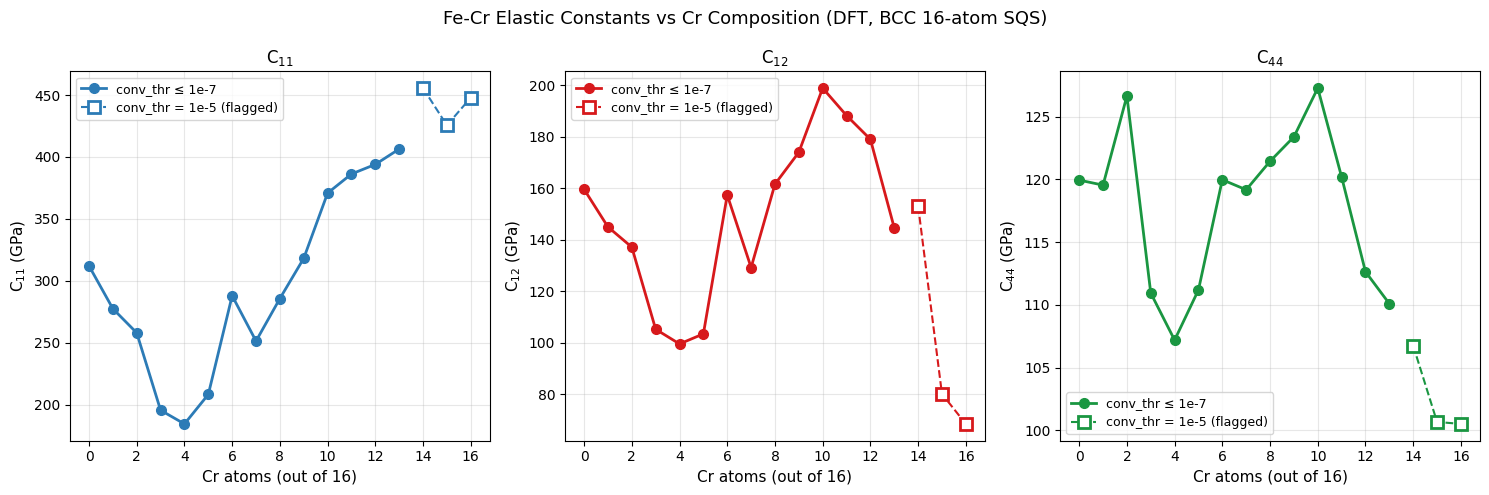

Saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/elastic_constants_vs_cr.png


In [19]:
fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle('Fe-Cr Elastic Constants vs Cr Composition (DFT, BCC 16-atom SQS)', fontsize=13)

props = [
    ('C11', 'C$_{11}$', '#2c7bb6'),
    ('C12', 'C$_{12}$', '#d7191c'),
    ('C44', 'C$_{44}$', '#1a9641'),
]

for ax, (col, label, color) in zip(axes, props):
    # Normal points
    mask_ok    = ~df_ok['loose_thr']
    mask_loose = df_ok['loose_thr']

    ax.plot(df_ok.loc[mask_ok, 'cr_count'], df_ok.loc[mask_ok, col],
            'o-', color=color, lw=2, ms=7, label='conv_thr ≤ 1e-7')

    ax.plot(df_ok.loc[mask_loose, 'cr_count'], df_ok.loc[mask_loose, col],
            's--', color=color, lw=1.5, ms=8, mfc='white', mew=2,
            label='conv_thr = 1e-5 (flagged)')

    ax.set_xlabel('Cr atoms (out of 16)', fontsize=11)
    ax.set_ylabel(f'{label} (GPa)', fontsize=11)
    ax.set_title(label, fontsize=12)
    ax.xaxis.set_major_locator(ticker.MultipleLocator(2))
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUT_DIR / 'elastic_constants_vs_cr.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/elastic_constants_vs_cr.png')

## Cell 5 — Plot: Bulk Modulus & Zener Anisotropy

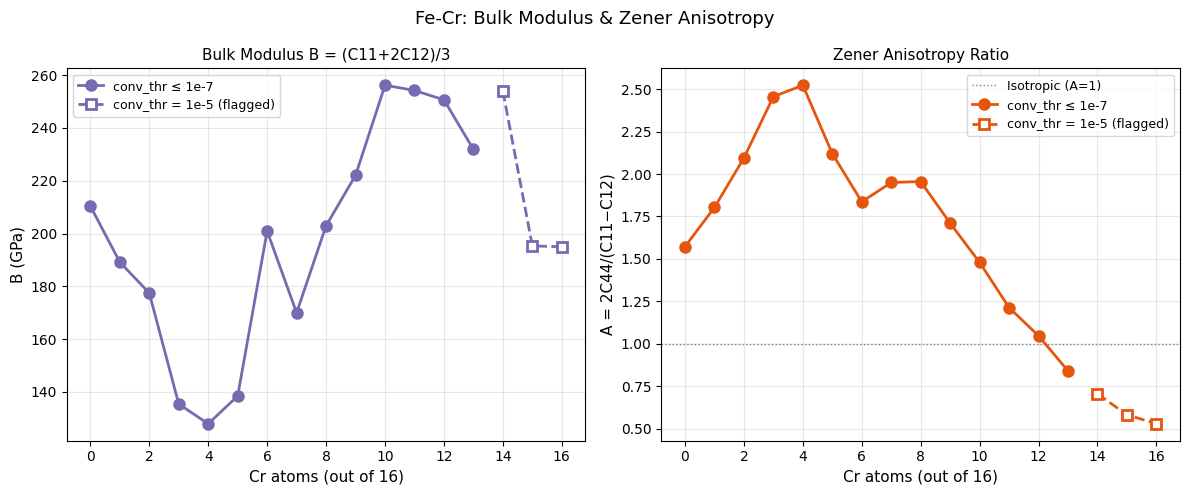

Saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/bulk_modulus_zener.png


In [20]:
df_ok = df_ok.copy()
# Zener anisotropy ratio A = 2*C44 / (C11 - C12)
df_ok['A'] = 2 * df_ok['C44'] / (df_ok['C11'] - df_ok['C12'])

fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(12, 5))
fig.suptitle('Fe-Cr: Bulk Modulus & Zener Anisotropy', fontsize=13)

# Bulk modulus
for loose, marker, ls, label in [(False,'o','-','conv_thr ≤ 1e-7'),
                                   (True, 's','--','conv_thr = 1e-5 (flagged)')]:
    sub = df_ok[df_ok['loose_thr'] == loose]
    ax1.plot(sub['cr_count'], sub['B'], marker+ls,
             color='#756bb1', lw=2, ms=7,
             mfc='white' if loose else '#756bb1', mew=2, label=label)
ax1.set_xlabel('Cr atoms (out of 16)', fontsize=11)
ax1.set_ylabel('B (GPa)', fontsize=11)
ax1.set_title('Bulk Modulus B = (C11+2C12)/3', fontsize=11)
ax1.grid(True, alpha=0.3)
ax1.legend(fontsize=9)

# Zener ratio
ax2.axhline(1.0, color='gray', lw=1, ls=':', label='Isotropic (A=1)')
for loose, marker, ls, label in [(False,'o','-','conv_thr ≤ 1e-7'),
                                   (True, 's','--','conv_thr = 1e-5 (flagged)')]:
    sub = df_ok[df_ok['loose_thr'] == loose]
    ax2.plot(sub['cr_count'], sub['A'], marker+ls,
             color='#e6550d', lw=2, ms=7,
             mfc='white' if loose else '#e6550d', mew=2, label=label)
ax2.set_xlabel('Cr atoms (out of 16)', fontsize=11)
ax2.set_ylabel('A = 2C44/(C11−C12)', fontsize=11)
ax2.set_title('Zener Anisotropy Ratio', fontsize=11)
ax2.grid(True, alpha=0.3)
ax2.legend(fontsize=9)

plt.tight_layout()
fig.savefig(OUT_DIR / 'bulk_modulus_zener.png', dpi=150, bbox_inches='tight')
plt.show()
print(f'Saved → {OUT_DIR}/bulk_modulus_zener.png')

## Cell 6 — Save Summary CSV & Text Report

In [21]:
# CSV
csv_path = OUT_DIR / 'elastic_constants_fecr.csv'
df_ok.to_csv(csv_path, index=False)
print(f'CSV saved → {csv_path}')

# Text summary
txt_path = OUT_DIR / 'elastic_constants_summary.txt'
with open(txt_path, 'w') as f:
    f.write('Fe-Cr Elastic Constants — DFT Summary\n')
    f.write('=' * 50 + '\n\n')
    f.write('System: BCC Fe-Cr, 16-atom SQS supercell\n')
    f.write('Code: Quantum ESPRESSO 7.3.1\n')
    f.write('Strain amplitude: ε = ±0.01\n')
    f.write('Units: GPa\n')
    f.write('NOTE: fe02cr14, fe01cr15, fe00cr16 used conv_thr=1e-5 (AFM init)\n\n')
    f.write(f'{"Tag":<12} {"Cr":>4} {"C11":>8} {"C12":>8} {"C44":>8} {"B":>8} {"A":>8} {"Flag":<6}\n')
    f.write('-' * 62 + '\n')
    for _, r in df_ok.iterrows():
        flag = '⚠️' if r['loose_thr'] else ''
        f.write(f"{r['tag']:<12} {int(r['cr_count']):>4} {r['C11']:>8.2f} "
                f"{r['C12']:>8.2f} {r['C44']:>8.2f} {r['B']:>8.2f} "
                f"{r['A']:>8.3f} {flag:<6}\n")
    f.write('\n' + '=' * 50 + '\n')
    f.write(f'Total tags: {len(df_ok)}\n')
    f.write(f'Flagged (loose conv_thr): {df_ok["loose_thr"].sum()}\n')

print(f'Summary saved → {txt_path}')
print('\n--- Done ---')

CSV saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/elastic_constants_fecr.csv
Summary saved → /home/sayeed/dft_projects/fe-cr_cu-ni_DFT/analysis/elastic_constants_summary.txt

--- Done ---
